In [1]:
import pandas as pd
import sqlite3

In [2]:
db_file = "../data/checking-logs.sqlite"
conn = sqlite3.connect(db_file)

Create exactly the same graph as the one below, including both values and style:
- Analyze only the users, not the admins.
- Analyze only the dates when there were both views and checker commits.
- The font size should be 8.
- The size of the figure should be (15, 8).

In [34]:
query = """
WITH a AS(
SELECT DATE(datetime) AS date, COUNT(DATE(datetime)) AS views
FROM pageviews 
WHERE uid LIKE 'user_%' 
GROUP BY DATE(datetime)
),
b AS(
SELECT DATE(timestamp) AS date, COUNT(DATE(timestamp)) AS commits
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY DATE(timestamp)
)

SELECT a.date, a.views, b. commits
FROM a 
JOIN b ON a.date = b.date
"""
visits_df = pd.read_sql(query, conn, parse_dates=['date'])
print(visits_df)

         date  views  commits
0  2020-04-17      1       23
1  2020-04-18     23       69
2  2020-04-19     15       33
3  2020-04-21      3       25
4  2020-04-22      1       28
5  2020-04-23      5       43
6  2020-04-25      1      104
7  2020-04-26      8      261
8  2020-04-28      2        5
9  2020-04-29      4       17
10 2020-04-30      9       53
11 2020-05-01      3       60
12 2020-05-02      6      242
13 2020-05-03     19      180
14 2020-05-04      1       37
15 2020-05-05      1      139
16 2020-05-06      3        2
17 2020-05-07      2       52
18 2020-05-08     48       87
19 2020-05-09     19       86
20 2020-05-10    110      143
21 2020-05-11    200      186
22 2020-05-12     85      323
23 2020-05-13    102      211
24 2020-05-14    187      575
25 2020-05-15     29       10
26 2020-05-16      4        4
27 2020-05-17      9       48
28 2020-05-18     51        3
29 2020-05-19     11       34
30 2020-05-20     12       28
31 2020-05-21     11       49


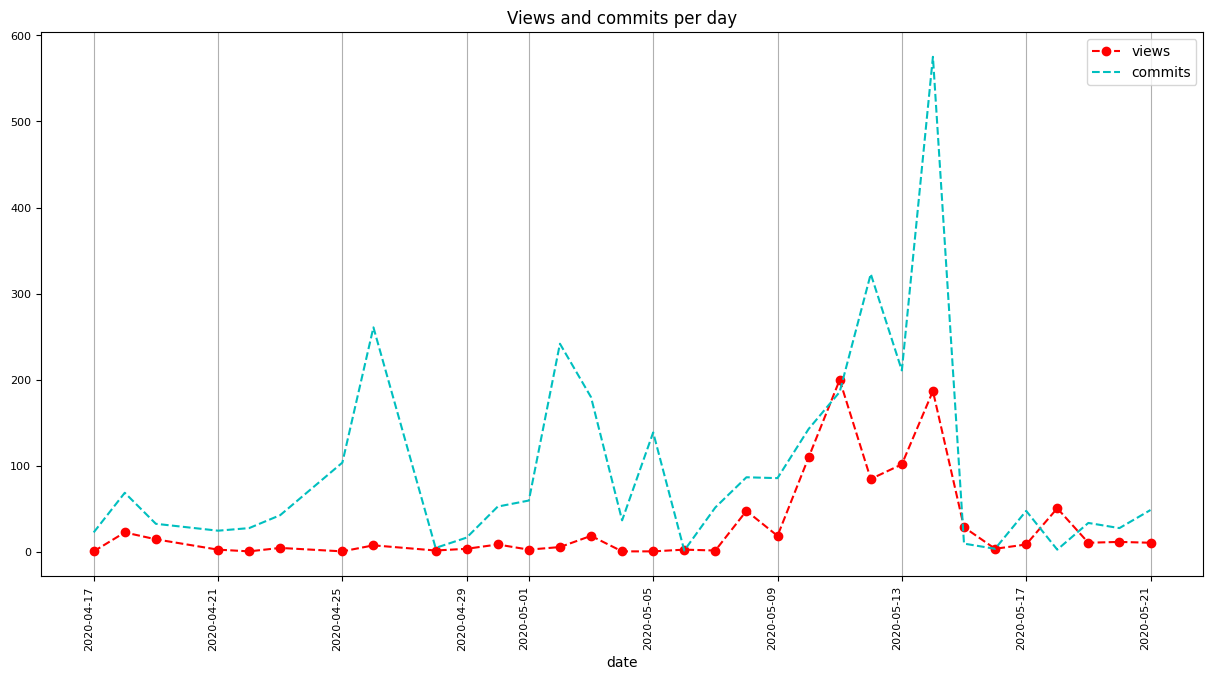

In [35]:
visits_df.set_index('date')
visits_df.plot(
    fontsize=8,
    kind='line',
    grid=True,
    figsize=(15, 8),
    title="Views and commits per day",
    x='date',
    y=['views', 'commits'],
    style=['r--o', 'c--'],
    rot=90,
).grid(axis='y')

How many times was the number of views larger than 150? 
The answer is 2.

In [36]:
conn.close()